In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [2]:
home_path = os.path.expanduser("~")

path = '/DataFiles'

era5 = nc.Dataset(home_path + path + "/data.nc")
firstMask = era5.variables['t2m']
tempMask = np.roll(firstMask, 1800, axis=2)
latInd = np.array(pd.read_csv(home_path + path +'/latInd.csv'))
erLat = era5.variables['latitude']
erLon = era5.variables['longitude']

ds = nc.Dataset(home_path + path +"/pr_sfc_Amon_CCSM4_past1000_085001-185012.nc")
tas = nc.Dataset(home_path + path +"/tas_sfc_Amon_CCSM4_past1000_085001-185012.nc")
lat = np.array(ds.variables['lat'])
lon = np.array(ds.variables['lon'])
tempPrecip = np.array(ds.variables['pr'])
tempTemp = np.array(tas.variables['tas'])




/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65313/296671328.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lat = np.array(ds.variables['lat'])
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65313/296671328.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon = np.array(ds.variables['lon'])
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65313/296671328.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy k

In [3]:
temp = np.zeros([1001, 192, 288])
precip = np.zeros([1001, 192, 288])

for i in range(1001):
    temp[i] = np.mean(tempTemp[i*12:(i+1)*12], axis=0)
    precip[i] = np.mean(tempPrecip[i*12:(i+1)*12], axis=0) * 31536000





tempRegrid = np.zeros([32, 3600])
secondRegrid = np.zeros([32, 7200])


i = 0
for item in latInd:
    tempRegrid[i, :] = tempMask[0, item[0]]
    i = i + 1


for i in range(32):
    secondRegrid[i, :7198] = np.dstack((tempRegrid[i, :-1], tempRegrid[i, :-1] + np.diff(tempRegrid[i]) / 2.0)).ravel()

print("reached")

reached


In [4]:
print("first)")

regrid = secondRegrid[:, ::25]



latLand = np.zeros([5794])
lonLand = np.zeros([5794])
prLand = np.zeros([5794, 1001])
tasLand = np.zeros([5794, 1001])

gridCount = 0

for i in range(32):
    for j in range(288):
        if regrid[i, j] > 0:
            latLand[gridCount] = lat[i]
            lonLand[gridCount] = lon[j]
            prLand[gridCount] = precip[:, i, j]
            tasLand[gridCount] = temp[:, i, j]
            gridCount = gridCount + 1

first)


/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


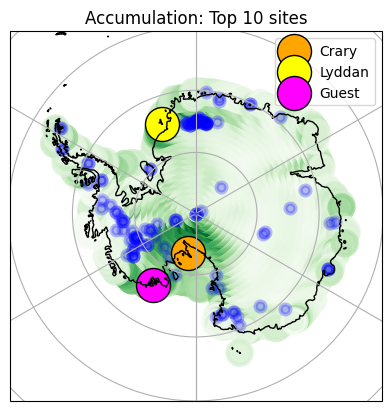

In [5]:
sites = np.array(pd.read_csv(home_path + path + '/Sites.csv'))

mreTemp = np.array(pd.read_csv(home_path + path + '/BS_MRE_temp_accumR.csv'))[:5793, 0]
mmeTemp = np.array(pd.read_csv(home_path + path + '/BS_MME_temp_accumR.csv'))[:5793, 0]
mreAccum = np.array(pd.read_csv(home_path + path + '/BS_MRE_accum_accumR.csv'))[:5793, 0]
mmeAccum = np.array(pd.read_csv(home_path + path + '/BS_MME_accum_accumR.csv'))[:5793, 0]
mreTempB = np.array(pd.read_csv(home_path + path + '/CON_MRE_temp_accumR.csv'))[:5793, 0]
mmeTempB = np.array(pd.read_csv(home_path + path + '/CON_MME_temp_accumR.csv'))[:5793, 0]
mreAccumB = np.array(pd.read_csv(home_path + path + '/CON_MRE_accum_accumR.csv'))[:5793, 0]
mmeAccumB = np.array(pd.read_csv(home_path + path + '/CON_MME_accum_accumR.csv'))[:5793, 0]


mreTempNorm = (mreTemp)/(np.max(mreTemp))
mmeTempNorm = (mmeTemp)/(np.max(mmeTemp))
mreAccumNorm = (mreAccum)/(np.max(mreAccum))
mmeAccumNorm = (mmeAccum)/(np.max(mmeAccum))
mreTempNormB = (mreTempB)/(np.max(mreTempB))
mmeTempNormB = (mmeTempB)/(np.max(mmeTempB))
mreAccumNormB = (mreAccumB)/(np.max(mreAccumB))
mmeAccumNormB = (mmeAccumB)/(np.max(mmeAccumB))

quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2)
accumQuad = np.sqrt(mreAccumNorm ** 2 + mmeAccumNorm ** 2)
tempQuad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2)
#quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2 + mreTempNormB ** 2 + mmeTempNormB **2 + mreAccumNormB ** 2 + mmeAccumNormB ** 2)

ax = plt.axes(projection=ccrs.SouthPolarStereo())
#ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]

plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=300, cmap=plt.cm.Greens, linewidth=3, alpha=0.75, zorder=1, transform=ccrs.PlateCarree())

plt.scatter(sites[:, 1], sites[:, 0], c='blue', s=50, linewidth=3, alpha=0.25, zorder=1, transform=ccrs.PlateCarree())


plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(-169, -83.4, c='orange', label='Crary', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(16.2, -70.4, c='yellow', label='Kamelryggen', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(-20.6, -74.37, c='yellow', label='Lyddan', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(-149, -76.4, c='magenta', label='Guest', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())

plt.legend()
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()

In [6]:
#from matplotlib.axes import Axes
#from cartopy.mpl.geoaxes import GeoAxes
#GeoAxes._pcolormesh_patched = Axes.pcolormesh
from scipy.interpolate import griddata

lon_grid = np.linspace(min(lonLand[:5793]), max(lonLand[:5793]), 100)
lat_grid = np.linspace(min(latLand[:5793]), max(latLand[:5793]), 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate scattered data onto the grid
#grid_values = griddata((lonLand[:5793], latLand[:5793]), accumQuad, (lon_mesh, lat_mesh), method='linear')

In [7]:
from scipy.spatial import cKDTree
import cartopy.util as cutil

# Build KD-tree of known points
tree = cKDTree(np.column_stack((lonLand[:5793], latLand[:5793])))

# Flatten the grid for querying
grid_points = np.column_stack((lon_mesh.ravel(), lat_mesh.ravel()))

# Query distance to the nearest original point
distances, _ = tree.query(grid_points)
distance_threshold = 1.0  # adjust based on spacing

# Reshape back to grid
distance_mask = distances.reshape(lon_mesh.shape) > distance_threshold

# Interpolate
grid_values = griddata((lonLand[:5793], latLand[:5793]), tempQuad, (lon_mesh, lat_mesh), method='linear')

# Replace NaNs and apply mask
#grid_values = np.nan_to_num(grid_values, nan=0.0)
grid_values[distance_mask] = np.nan

newLonMesh = cutil.add_cyclic_point(lon_mesh)
newLatMesh = cutil.add_cyclic_point(lat_mesh)
newGridVals = cutil.add_cyclic_point(grid_values)


/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


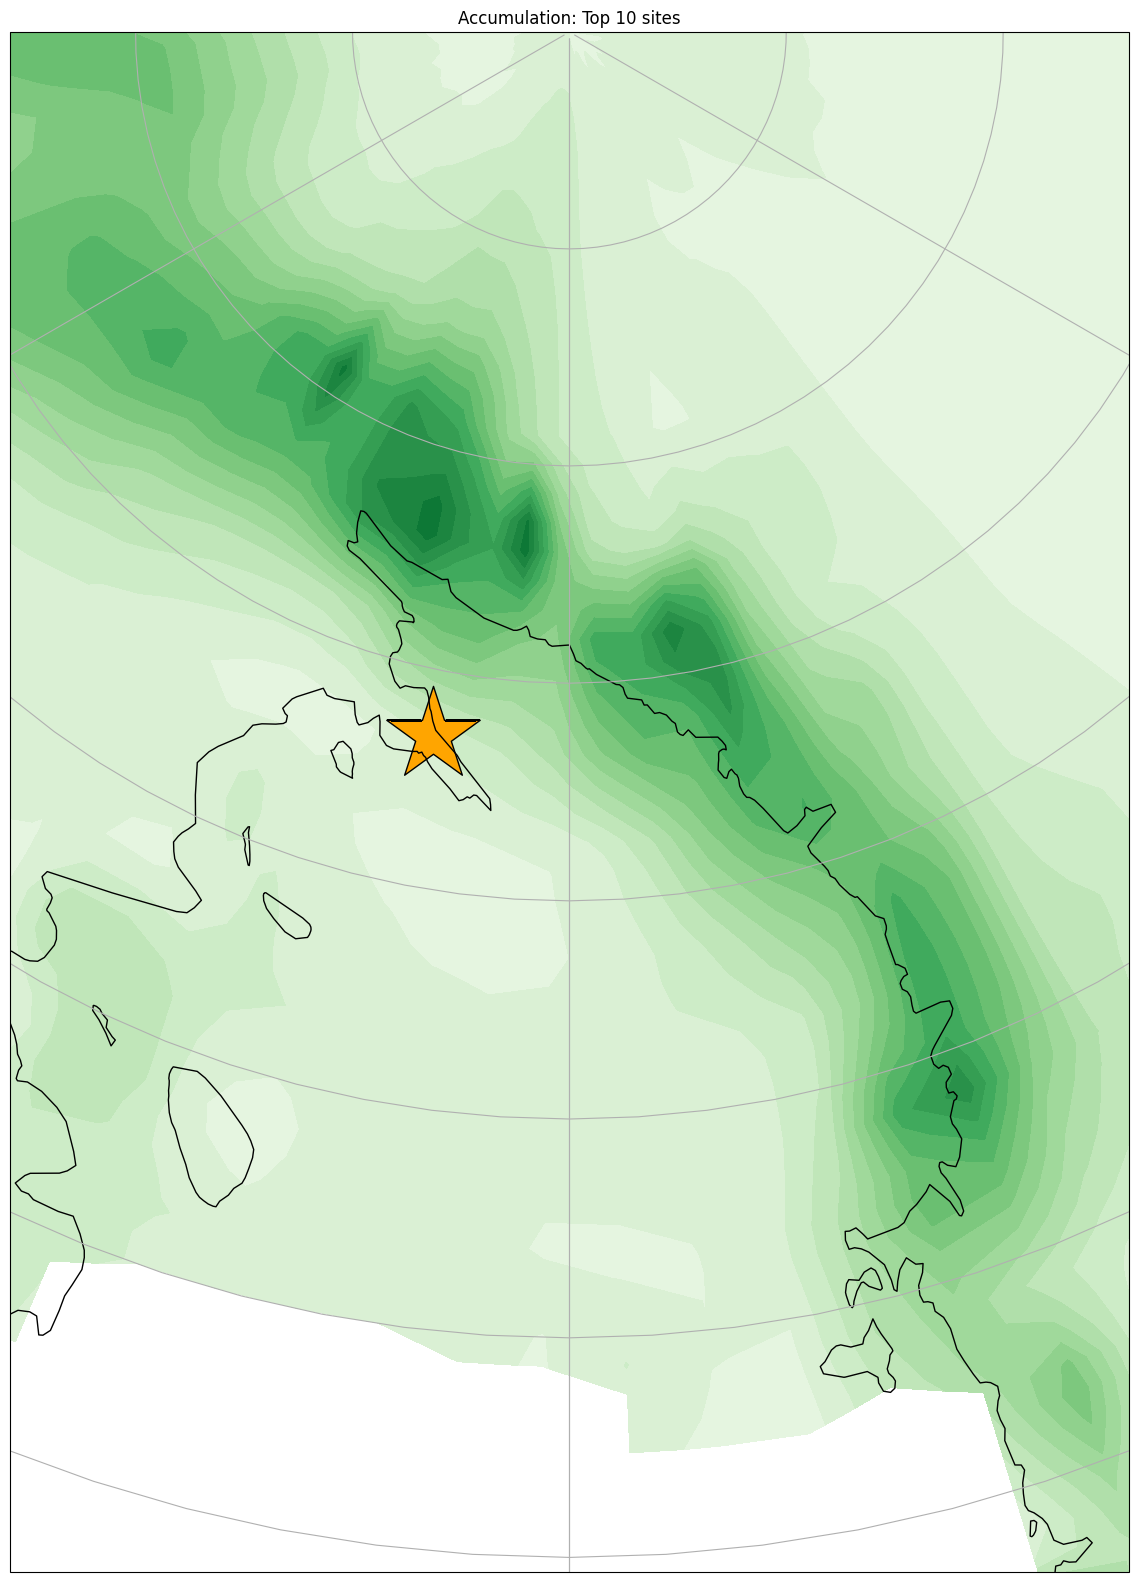

In [8]:





ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]
plt.contourf(lon_mesh, lat_mesh, grid_values, transform=ccrs.PlateCarree(), levels=20, cmap=plt.cm.Greens)
#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=5700, cmap=plt.cm.Greens, alpha=0.75, transform=ccrs.PlateCarree())


plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(-169, -83.4, c='orange', label='Crary', s=5000, marker='*', linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())


#plt.legend()
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()

/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


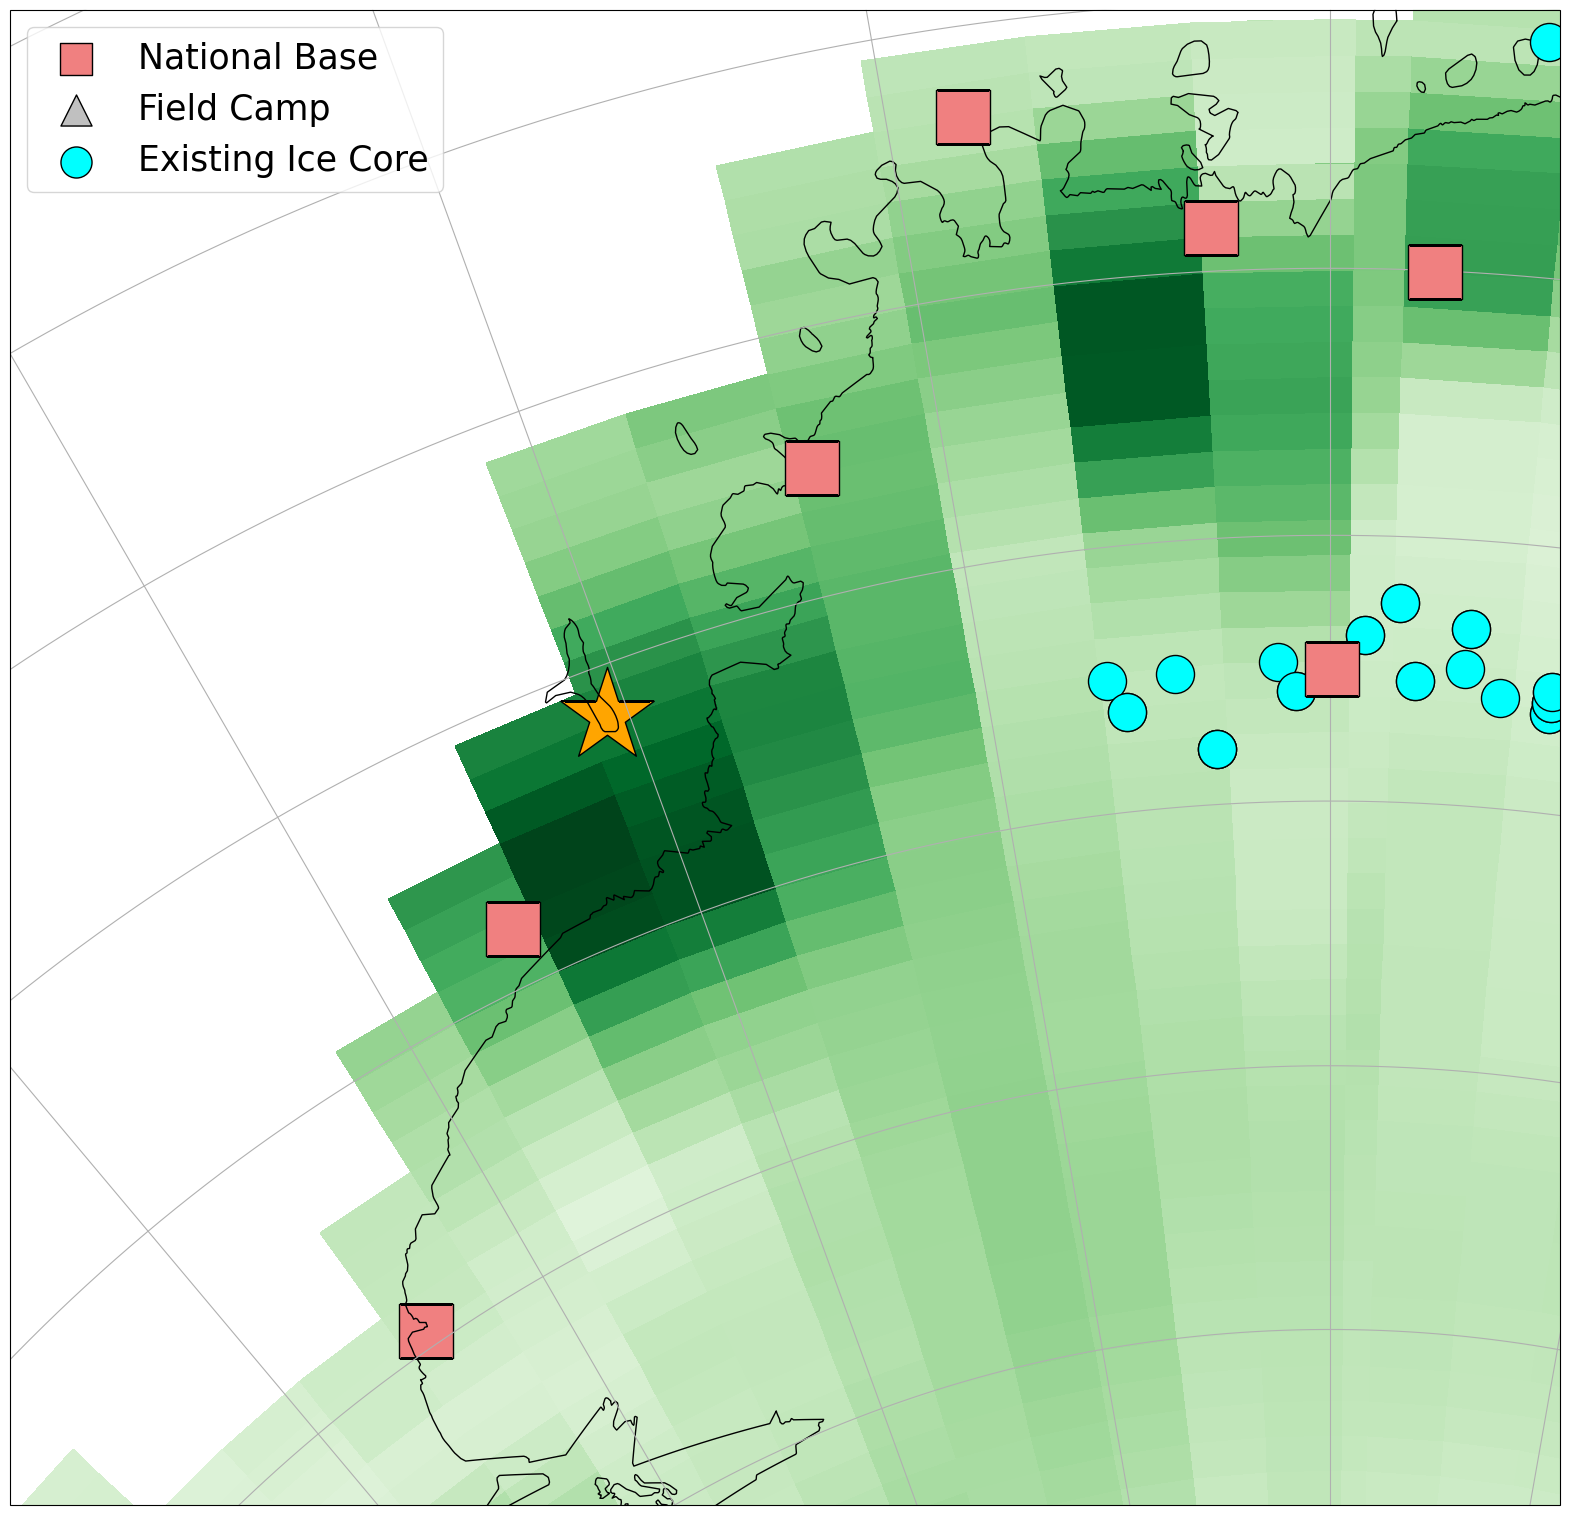

In [9]:


start = (166.668235, -77.846323)  # (lon, lat)
end = (-163.370783, -84.452983)
end2 = (-135, -86.3)
end3 = (-135, -90)


ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-30, 5, -80, -70], ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]
plt.pcolormesh(lon_mesh, lat_mesh, grid_values, zorder=0, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=5700, cmap=plt.cm.Greens, alpha=0.75, transform=ccrs.PlateCarree())

plt.plot([start[0], end[0], end2[0], end3[0]], [start[1], end[1], end2[1], end3[0]], color='red',  linestyle='--', zorder=1, linewidth=8, marker='o', transform=ccrs.Geodetic())
#plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(0,	90, c='lightcoral', s=500, linewidth=1, edgecolors='black', marker='s', label='National Base', zorder=3, transform=ccrs.PlateCarree())
plt.scatter(0,	-90, c='midnightblue', s=1000, linewidth=1, marker='s',  zorder=1, transform=ccrs.PlateCarree())
plt.scatter(166.668235, -77.846323, c='midnightblue', marker='s', zorder=3, s=1000, transform=ccrs.PlateCarree())

plt.scatter(-163.370783, -84.452983, c='silver', marker='^', s=1000, zorder=2, edgecolors='black', transform=ccrs.PlateCarree())
plt.scatter(-163.370783, 84.452983, label='Field Camp', c='silver', edgecolors='black', marker='^', s=500, transform=ccrs.PlateCarree())

plt.scatter(-169, -83.4, c='orange', s=7500, marker='*', linewidth=1, zorder=4, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, transform=ccrs.PlateCarree())
plt.scatter(0, 90, label='Existing Ice Core', c='cyan', linewidth=1, edgecolors='black', s=500, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(sites[:, 1], sites[:, 0], c='cyan', s=750, linewidth=1, edgecolors='black', zorder=2, transform=ccrs.PlateCarree())

plt.scatter(-20.6, -74.37, c='orange',  s=5000, marker='*', linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())

plt.scatter(-34.627588, -77.873696, c='lightcoral', s=1500, edgecolors='black', linewidth=1, marker='s',  zorder=1, transform=ccrs.PlateCarree())
plt.scatter(-25.508333, -75.568056, c='lightcoral', marker='s', edgecolors='black', linewidth=1, zorder=3, s=1500, transform=ccrs.PlateCarree())
plt.scatter(-13.40735, -73.042283, c='lightcoral', marker='s', edgecolors='black', linewidth=1, zorder=3, s=1500, transform=ccrs.PlateCarree())
plt.scatter(-8.274167, -70.674444, c='lightcoral', marker='s', edgecolors='black', linewidth=1, zorder=3, s=1500, transform=ccrs.PlateCarree())
plt.scatter(-2.828611, -71.673611, c='lightcoral', marker='s', edgecolors='black', linewidth=1, zorder=3, s=1500, transform=ccrs.PlateCarree())
plt.scatter(2.535138, -72.011662, c='lightcoral', marker='s', edgecolors='black', linewidth=1, zorder=3, s=1500, transform=ccrs.PlateCarree())
plt.scatter(0.066792, -75.001882, c='lightcoral', marker='s', edgecolors='black', linewidth=1, zorder=3, s=1500, transform=ccrs.PlateCarree())

plt.legend(fontsize=25, loc='upper left')
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()

/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


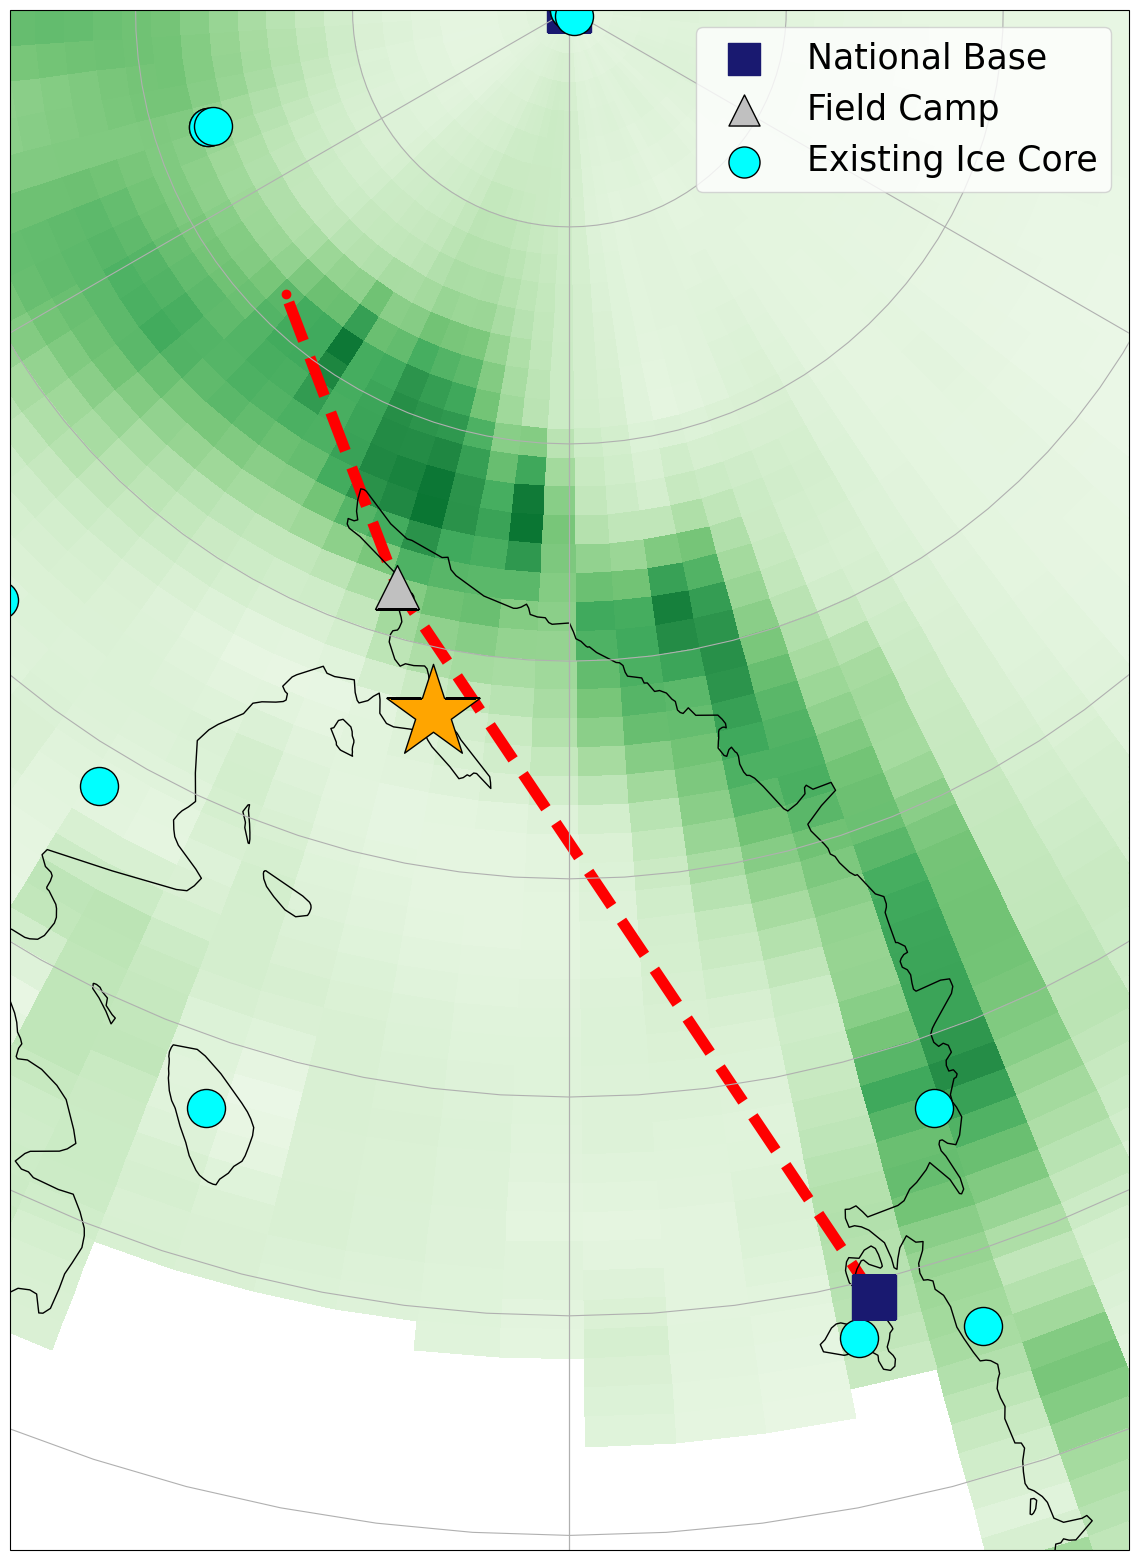

In [10]:


start = (166.668235, -77.846323)  # (lon, lat)
end = (-163.370783, -84.452983)
end2 = (-135, -86.3)
end3 = (-135, -90)


ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]
plt.pcolormesh(lon_mesh, lat_mesh, grid_values, zorder=0, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=5700, cmap=plt.cm.Greens, alpha=0.75, transform=ccrs.PlateCarree())

plt.plot([start[0], end[0], end2[0], end3[0]], [start[1], end[1], end2[1], end3[0]], color='red',  linestyle='--', zorder=1, linewidth=8, marker='o', transform=ccrs.Geodetic())
#plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(0,	90, c='midnightblue', s=500, linewidth=1, marker='s', label='National Base', zorder=3, transform=ccrs.PlateCarree())
plt.scatter(0,	-90, c='midnightblue', s=1000, linewidth=1, marker='s',  zorder=1, transform=ccrs.PlateCarree())
plt.scatter(166.668235, -77.846323, c='midnightblue', marker='s', zorder=3, s=1000, transform=ccrs.PlateCarree())

plt.scatter(-163.370783, -84.452983, c='silver', marker='^', s=1000, zorder=2, edgecolors='black', transform=ccrs.PlateCarree())
plt.scatter(-163.370783, 84.452983, label='Field Camp', c='silver', edgecolors='black', marker='^', s=500, transform=ccrs.PlateCarree())

plt.scatter(-169, -83.4, c='orange', s=5000, marker='*', linewidth=1, zorder=4, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, transform=ccrs.PlateCarree())
plt.scatter(0, 90, label='Existing Ice Core', c='cyan', linewidth=1, edgecolors='black', s=500, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(sites[:, 1], sites[:, 0], c='cyan', s=750, linewidth=1, edgecolors='black', zorder=2, transform=ccrs.PlateCarree())



plt.legend(fontsize=25)
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()

In [12]:
from scipy.spatial import cKDTree
import cartopy.util as cutil

# Build KD-tree of known points
tree = cKDTree(np.column_stack((lonLand[:5793], latLand[:5793])))

# Flatten the grid for querying
grid_points = np.column_stack((lon_mesh.ravel(), lat_mesh.ravel()))

# Query distance to the nearest original point
distances, _ = tree.query(grid_points)
distance_threshold = 1.0  # adjust based on spacing

# Reshape back to grid
distance_mask = distances.reshape(lon_mesh.shape) > distance_threshold

# Interpolate
grid_values = griddata((lonLand[:5793], latLand[:5793]), quad, (lon_mesh, lat_mesh), method='linear')

# Replace NaNs and apply mask
#grid_values = np.nan_to_num(grid_values, nan=0.0)
grid_values[distance_mask] = np.nan

newLonMesh = cutil.add_cyclic_point(lon_mesh)
newLatMesh = cutil.add_cyclic_point(lat_mesh)
newGridVals = cutil.add_cyclic_point(grid_values)


/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


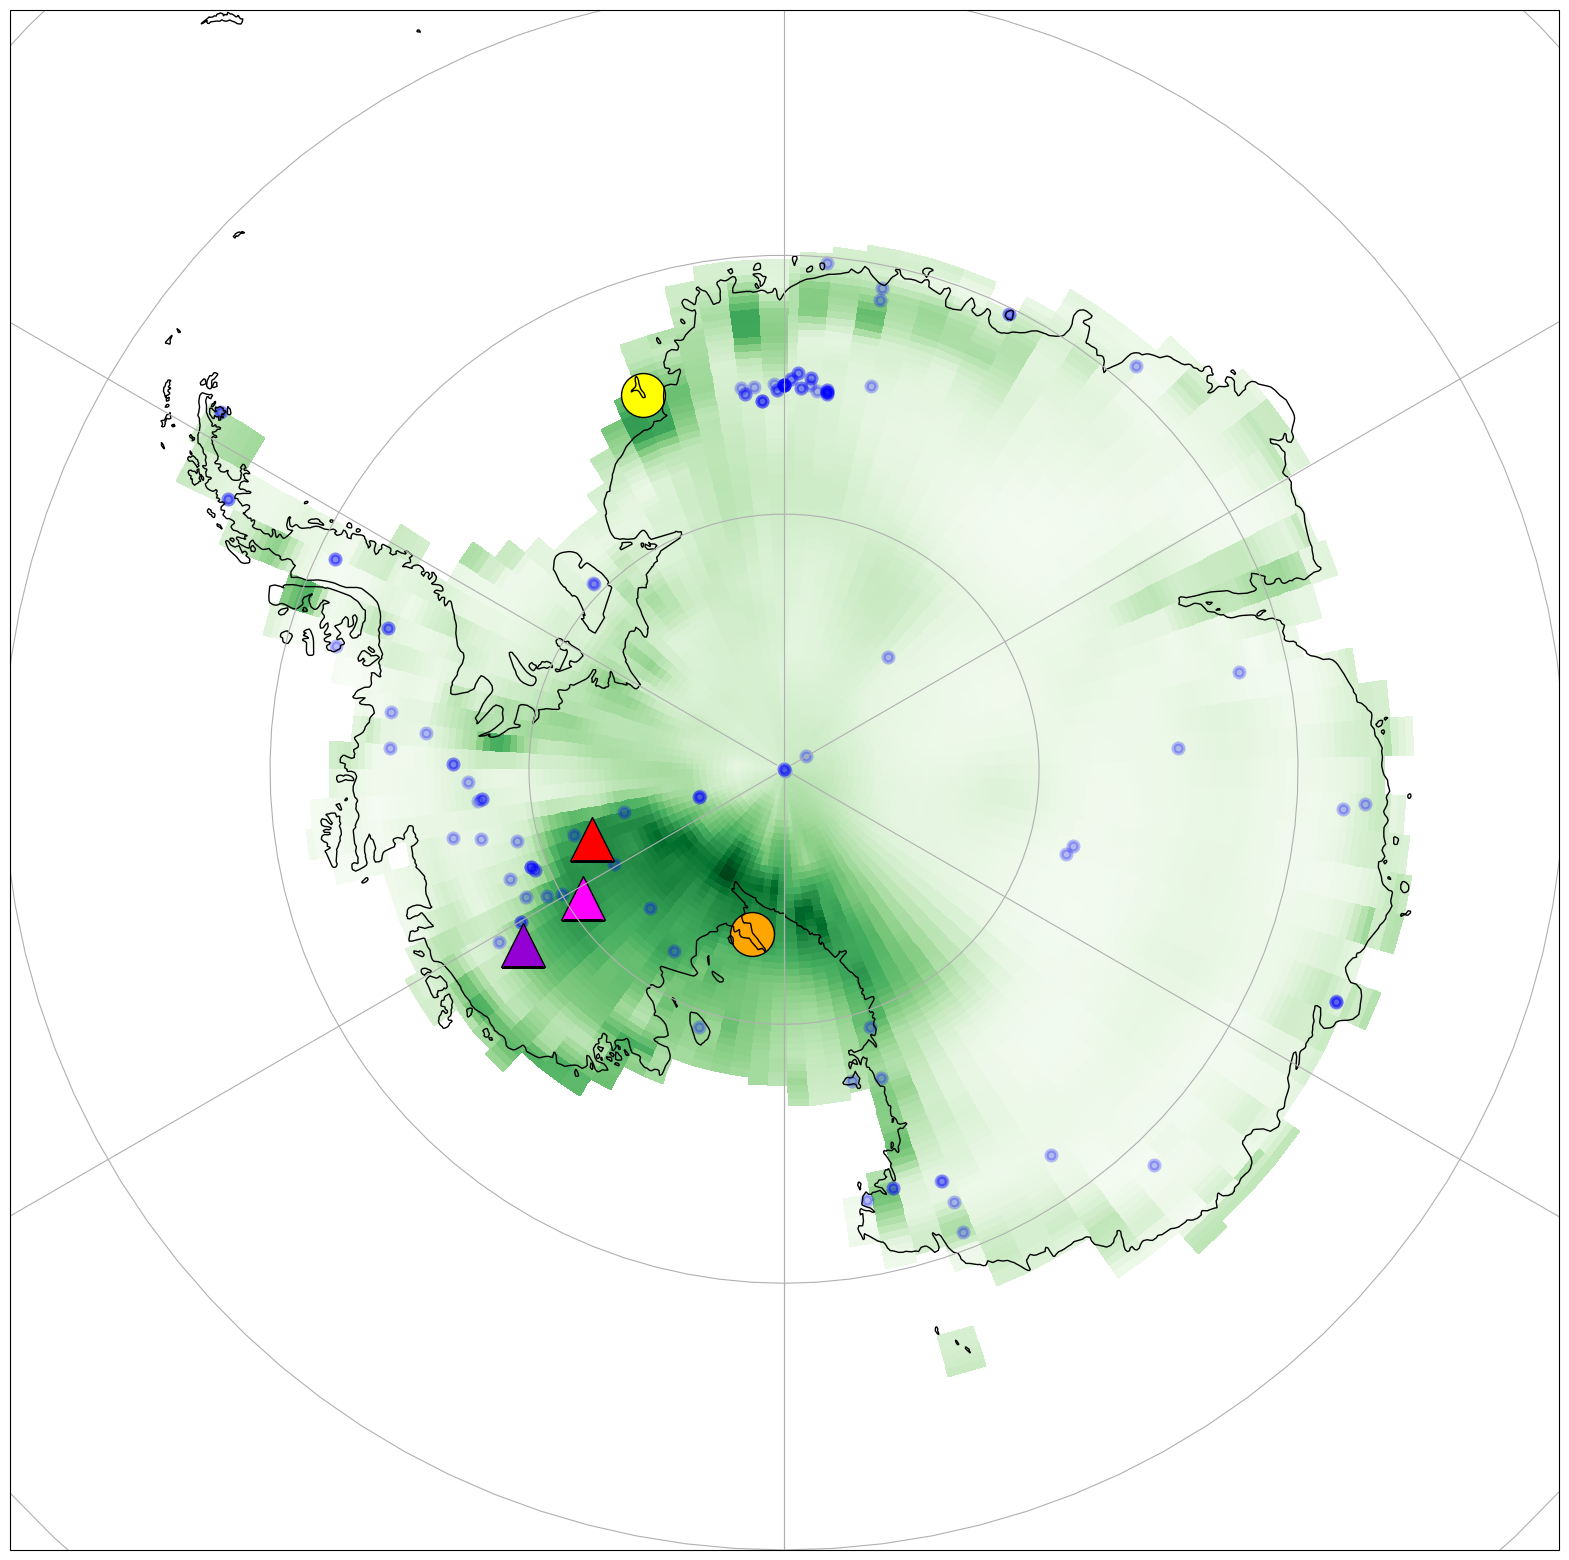

In [23]:
quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2)
#quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2 + mreTempNormB ** 2 + mmeTempNormB **2 + mreAccumNormB ** 2 + mmeAccumNormB ** 2)

ax = plt.axes(projection=ccrs.SouthPolarStereo())
#ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]

#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=300, cmap=plt.cm.Greens, linewidth=3, alpha=0.75, zorder=1, transform=ccrs.PlateCarree())
#plt.pcolormesh(newLonMesh, newLatMesh, newGridVals, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.pcolormesh(lon_mesh, lat_mesh, grid_values, zorder=0, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.scatter(sites[:, 1], sites[:, 0], c='blue', s=50, linewidth=3, alpha=0.25, zorder=1, transform=ccrs.PlateCarree())


#plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(-169, -83.4, c='orange', label='Crary', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(16.2, -70.4, c='yellow', label='Kamelryggen', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(-20.6, -74.37, c='yellow', label='Lyddan', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(-127, -74.5, c='magenta', label='Dean', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())

plt.scatter(237.37,	-80.62, c='fuchsia', s=1000, marker='^', label='ITASE-99-01', linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(249.9918,	-82.001, c='red', marker='^', label='ITASE-01-02', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(236.005,	-77.683, c='darkviolet', marker='^', label='ITASE-00-05', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())

#plt.legend(fontsize=29)
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()

/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


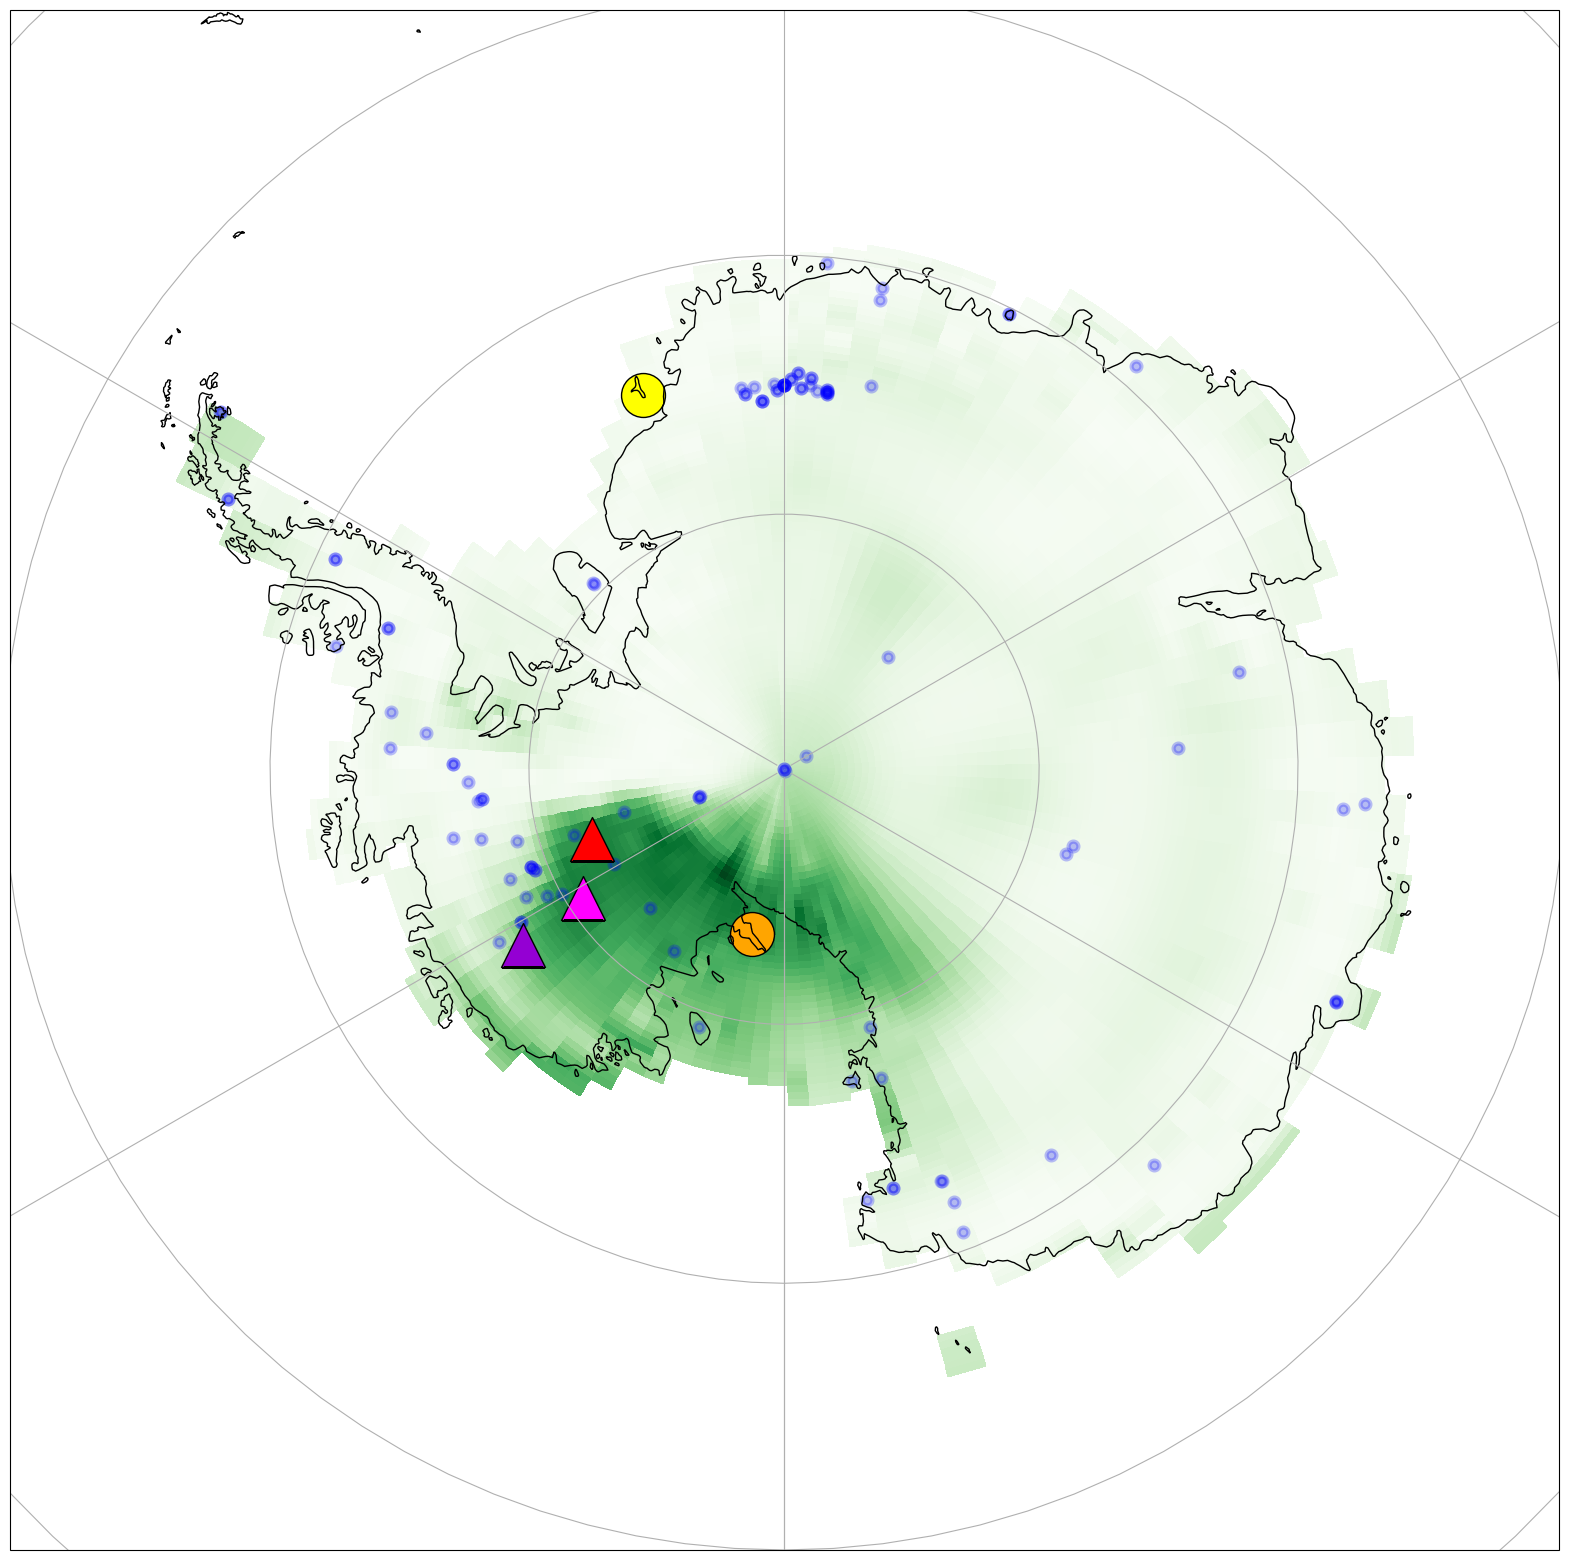

In [24]:
from scipy.spatial import cKDTree
import cartopy.util as cutil

# Build KD-tree of known points
tree = cKDTree(np.column_stack((lonLand[:5793], latLand[:5793])))

# Flatten the grid for querying
grid_points = np.column_stack((lon_mesh.ravel(), lat_mesh.ravel()))

# Query distance to the nearest original point
distances, _ = tree.query(grid_points)
distance_threshold = 1.0  # adjust based on spacing

# Reshape back to grid
distance_mask = distances.reshape(lon_mesh.shape) > distance_threshold

# Interpolate
grid_values = griddata((lonLand[:5793], latLand[:5793]), accumQuad, (lon_mesh, lat_mesh), method='linear')

# Replace NaNs and apply mask
#grid_values = np.nan_to_num(grid_values, nan=0.0)
grid_values[distance_mask] = np.nan

newLonMesh = cutil.add_cyclic_point(lon_mesh)
newLatMesh = cutil.add_cyclic_point(lat_mesh)
newGridVals = cutil.add_cyclic_point(grid_values)

#quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2 + mreTempNormB ** 2 + mmeTempNormB **2 + mreAccumNormB ** 2 + mmeAccumNormB ** 2)

ax = plt.axes(projection=ccrs.SouthPolarStereo())
#ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]

#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=300, cmap=plt.cm.Greens, linewidth=3, alpha=0.75, zorder=1, transform=ccrs.PlateCarree())
#plt.pcolormesh(newLonMesh, newLatMesh, newGridVals, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.pcolormesh(lon_mesh, lat_mesh, grid_values, zorder=0, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.scatter(sites[:, 1], sites[:, 0], c='blue', s=50, linewidth=3, alpha=0.25, zorder=1, transform=ccrs.PlateCarree())


#plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(-169, -83.4, c='orange', label='Crary', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(16.2, -70.4, c='yellow', label='Kamelryggen', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(-20.6, -74.37, c='yellow', label='Lyddan', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(-127, -74.5, c='magenta', label='Dean', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())

plt.scatter(237.37,	-80.62, c='fuchsia', s=1000, marker='^', label='ITASE-99-01', linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(249.9918,	-82.001, c='red', marker='^', label='ITASE-01-02', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(236.005,	-77.683, c='darkviolet', marker='^', label='ITASE-00-05', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())

#plt.legend(fontsize=29)
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()

/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


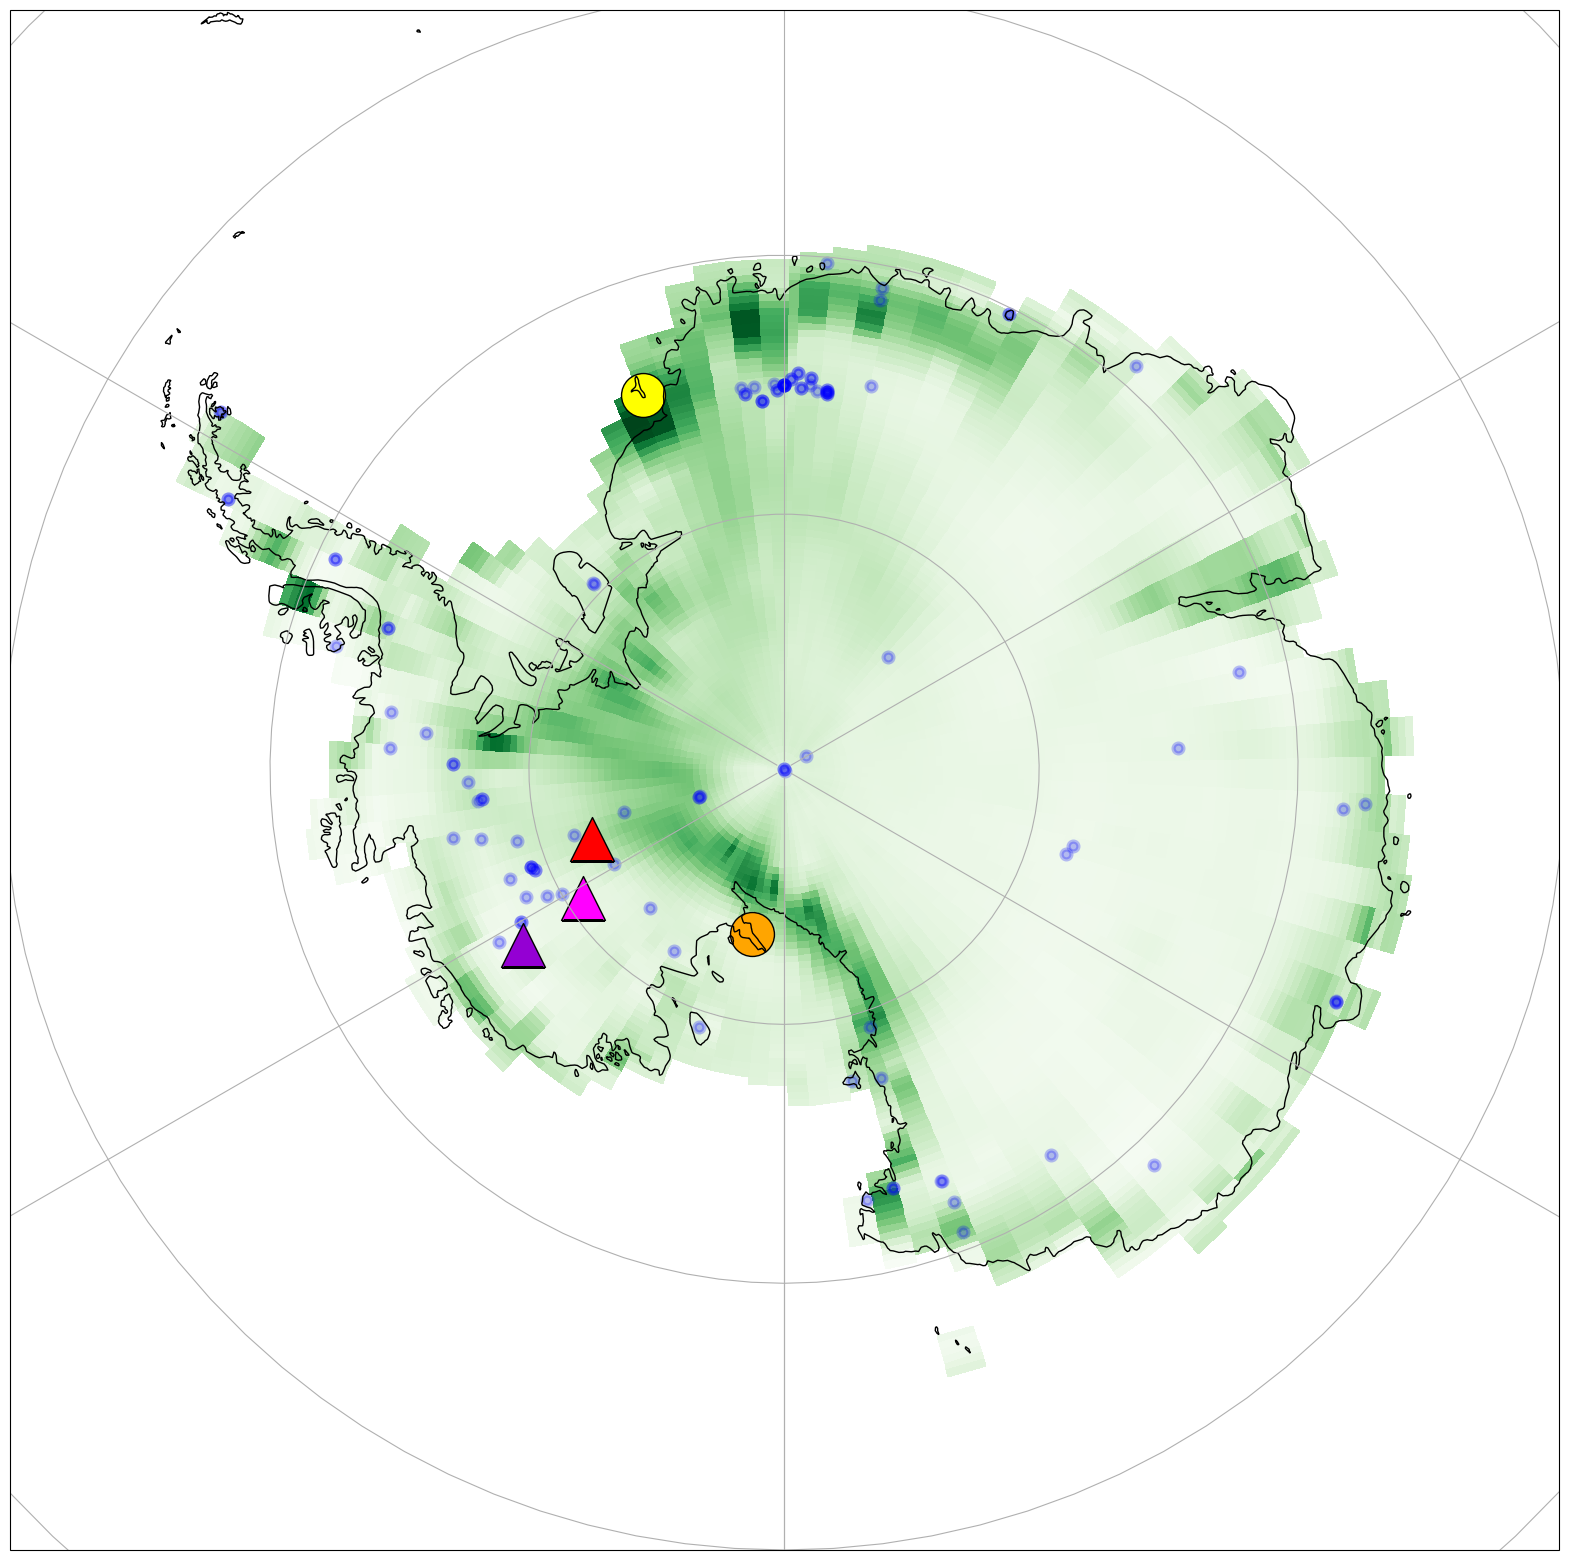

In [25]:
from scipy.spatial import cKDTree
import cartopy.util as cutil

# Build KD-tree of known points
tree = cKDTree(np.column_stack((lonLand[:5793], latLand[:5793])))

# Flatten the grid for querying
grid_points = np.column_stack((lon_mesh.ravel(), lat_mesh.ravel()))

# Query distance to the nearest original point
distances, _ = tree.query(grid_points)
distance_threshold = 1.0  # adjust based on spacing

# Reshape back to grid
distance_mask = distances.reshape(lon_mesh.shape) > distance_threshold

# Interpolate
grid_values = griddata((lonLand[:5793], latLand[:5793]), tempQuad, (lon_mesh, lat_mesh), method='linear')

# Replace NaNs and apply mask
#grid_values = np.nan_to_num(grid_values, nan=0.0)
grid_values[distance_mask] = np.nan

newLonMesh = cutil.add_cyclic_point(lon_mesh)
newLatMesh = cutil.add_cyclic_point(lat_mesh)
newGridVals = cutil.add_cyclic_point(grid_values)

#quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2 + mreTempNormB ** 2 + mmeTempNormB **2 + mreAccumNormB ** 2 + mmeAccumNormB ** 2)

ax = plt.axes(projection=ccrs.SouthPolarStereo())
#ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]

#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=300, cmap=plt.cm.Greens, linewidth=3, alpha=0.75, zorder=1, transform=ccrs.PlateCarree())
#plt.pcolormesh(newLonMesh, newLatMesh, newGridVals, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.pcolormesh(lon_mesh, lat_mesh, grid_values, zorder=0, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.scatter(sites[:, 1], sites[:, 0], c='blue', s=50, linewidth=3, alpha=0.25, zorder=1, transform=ccrs.PlateCarree())


#plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(-169, -83.4, c='orange', label='Crary', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(16.2, -70.4, c='yellow', label='Kamelryggen', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(-20.6, -74.37, c='yellow', label='Lyddan', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(-127, -74.5, c='magenta', label='Dean', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())

plt.scatter(237.37,	-80.62, c='fuchsia', s=1000, marker='^', label='ITASE-99-01', linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(249.9918,	-82.001, c='red', marker='^', label='ITASE-01-02', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(236.005,	-77.683, c='darkviolet', marker='^', label='ITASE-00-05', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())

#plt.legend(fontsize=29)
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()

/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/Users/advik/optimal-sensor/.venv/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


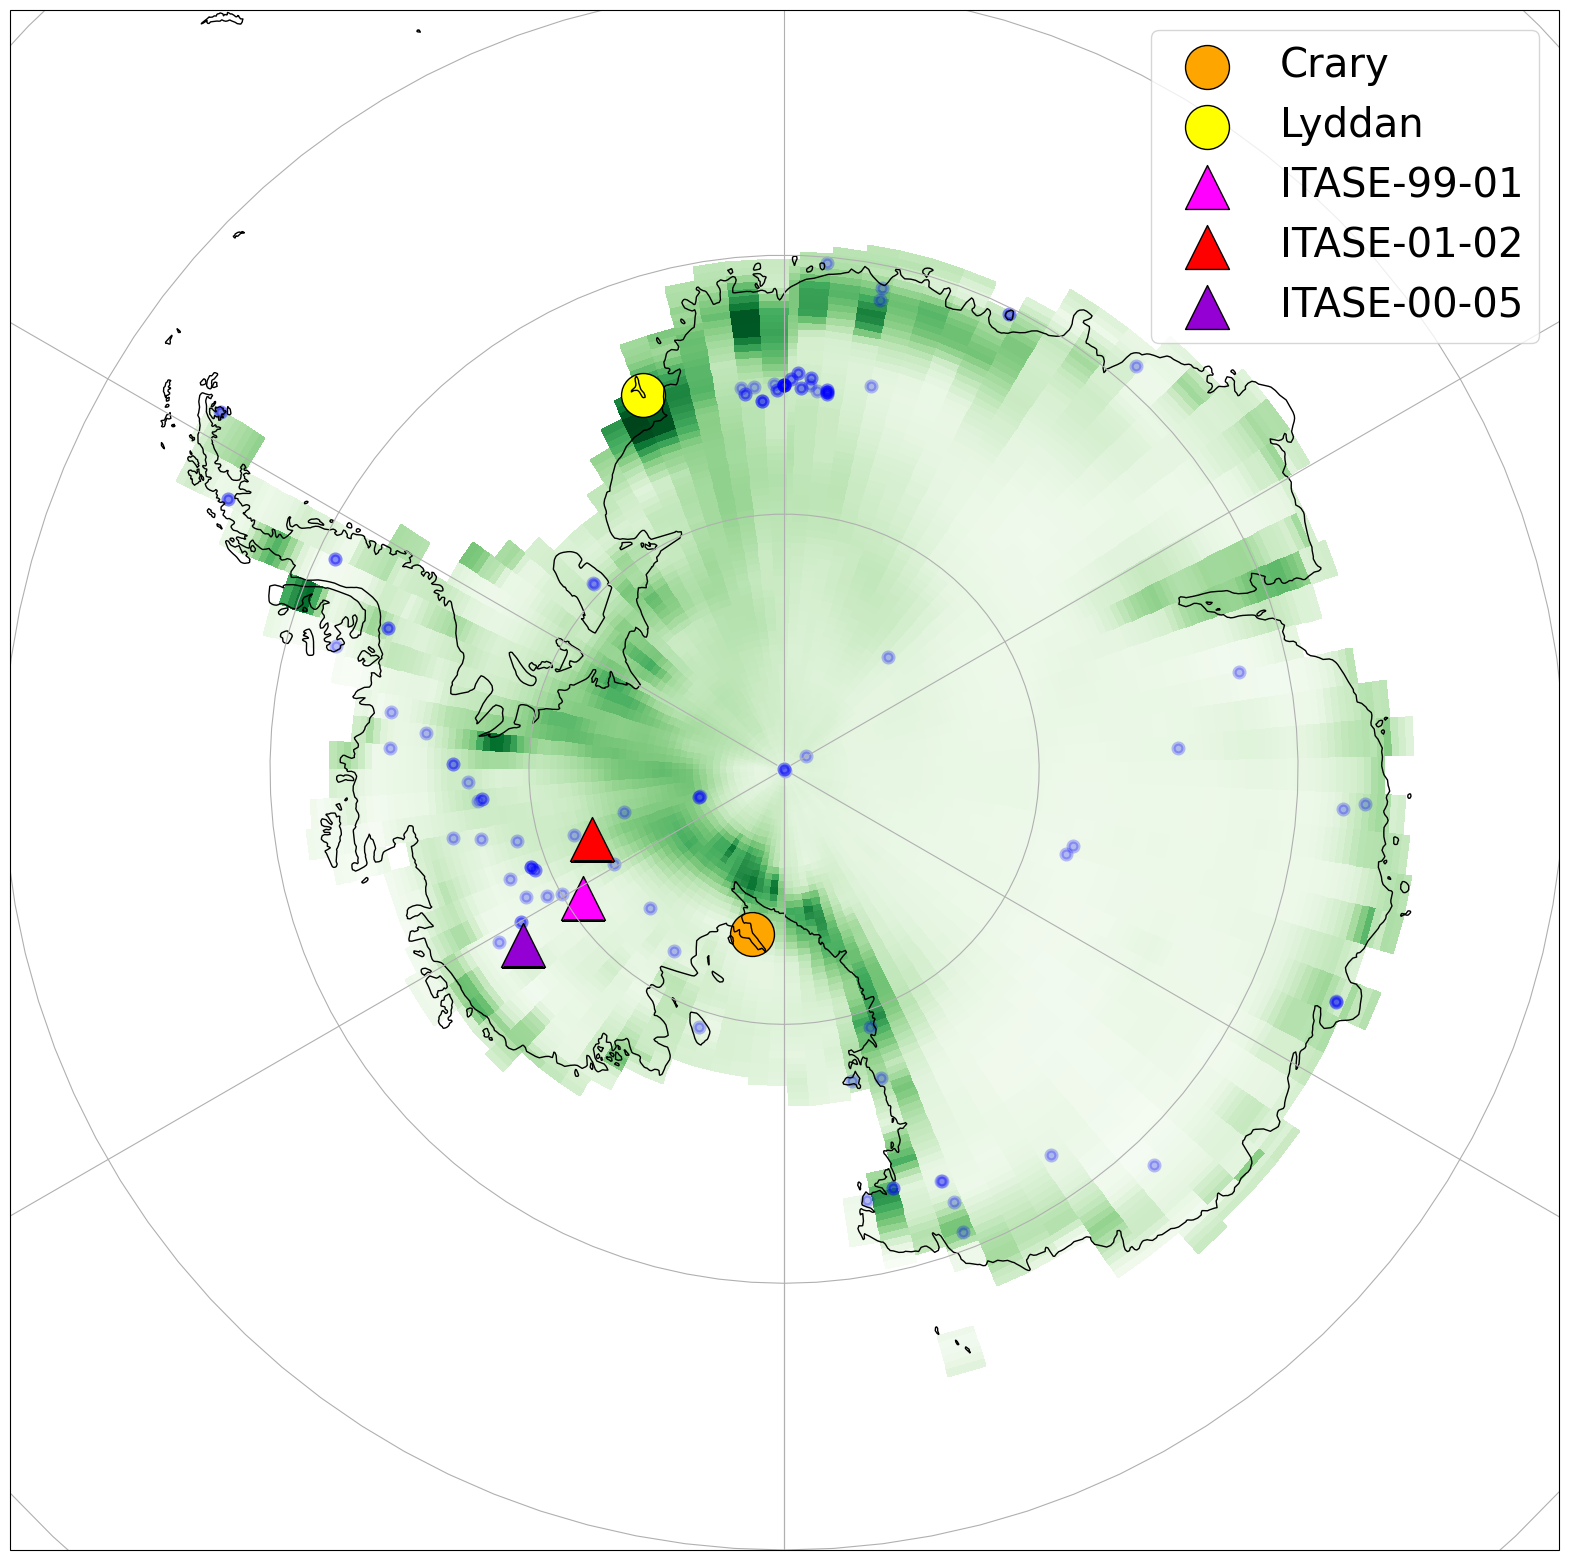

In [26]:
quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2)
#quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2 + mreTempNormB ** 2 + mmeTempNormB **2 + mreAccumNormB ** 2 + mmeAccumNormB ** 2)

ax = plt.axes(projection=ccrs.SouthPolarStereo())
#ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]

#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=300, cmap=plt.cm.Greens, linewidth=3, alpha=0.75, zorder=1, transform=ccrs.PlateCarree())
#plt.pcolormesh(newLonMesh, newLatMesh, newGridVals, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.pcolormesh(lon_mesh, lat_mesh, grid_values, zorder=0, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.scatter(sites[:, 1], sites[:, 0], c='blue', s=50, linewidth=3, alpha=0.25, zorder=1, transform=ccrs.PlateCarree())


#plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(-169, -83.4, c='orange', label='Crary', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(16.2, -70.4, c='yellow', label='Kamelryggen', s=600, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
plt.scatter(-20.6, -74.37, c='yellow', label='Lyddan', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())
#plt.scatter(-127, -74.5, c='magenta', label='Dean', s=1000, linewidth=1, edgecolors='black', alpha=1, cmap=plt.cm.Reds, vmin=-10, vmax=10, zorder=1, transform=ccrs.PlateCarree())

plt.scatter(237.37,	-80.62, c='fuchsia', s=1000, marker='^', label='ITASE-99-01', linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(249.9918,	-82.001, c='red', marker='^', label='ITASE-01-02', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())
plt.scatter(236.005,	-77.683, c='darkviolet', marker='^', label='ITASE-00-05', s=1000, linewidth=1, edgecolors='black', zorder=1, transform=ccrs.PlateCarree())

plt.legend(fontsize=29)
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()